# Customer Segmentation
Tujuan: Menganalisis dan mengidentifikasi segmen pelanggan.

## 1. Data Loading
Tujuan: Mengambil dan menampilkan gambaran dari data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/telco_clean.csv")
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,...,29.85,29.85,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,1,0,...,56.95,1889.50,0,0,0,0,0,0,0,1
2,1,0,0,0,2,1,1,1,0,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,1,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,1,0,0,1,0


## 2. Pisahkan Target
Tujuan: Memisahkan fitur dan target dalam dataset.

In [2]:
X = df.drop("Churn", axis=1)
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,...,1,29.85,29.85,1,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,1,0,...,0,56.95,1889.50,0,0,0,0,0,0,1
2,1,0,0,0,2,1,1,1,0,0,...,1,53.85,108.15,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,1,1,...,0,42.30,1840.75,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,0,0,1,0,0,1,0


## 3. Scaling
Tujuan: Mengubah rentang nilai fitur (variabel) dalam dataset agar seragam untuk mencegah bias pada model.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 4. KMeans
Tujuan: Mencari nilai K untuk KMeans.

In [4]:
wcss = []

from sklearn.cluster import KMeans

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

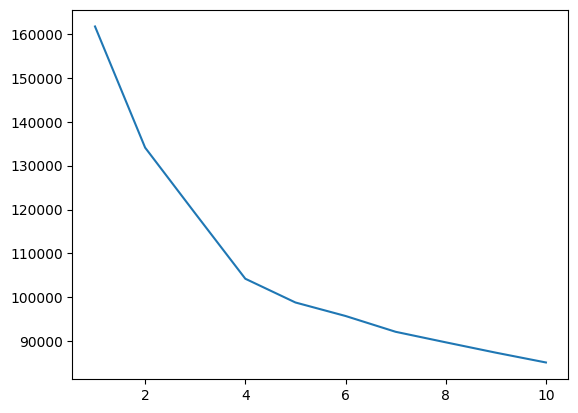

In [5]:
plt.plot(range(1,11), wcss)

## 5. Silhouette Score
Tujuan: Mengevaluasi kualitas model klasterisasi KMeans.

In [6]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

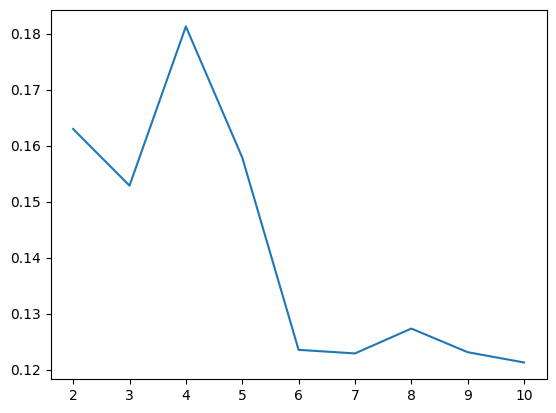

In [7]:
plt.plot(range(2,11), scores)

## 6. KMeans Final
Tujuan: Menggunakan k terbaik untuk clustering KMeans.

Keputusan: Berdasarkan beberapa percobaan diatas, kita akan menggunakan k = 4 untuk clustering.

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

## 7. Analysis
Tujuan: Menganalisis hasil clustering.

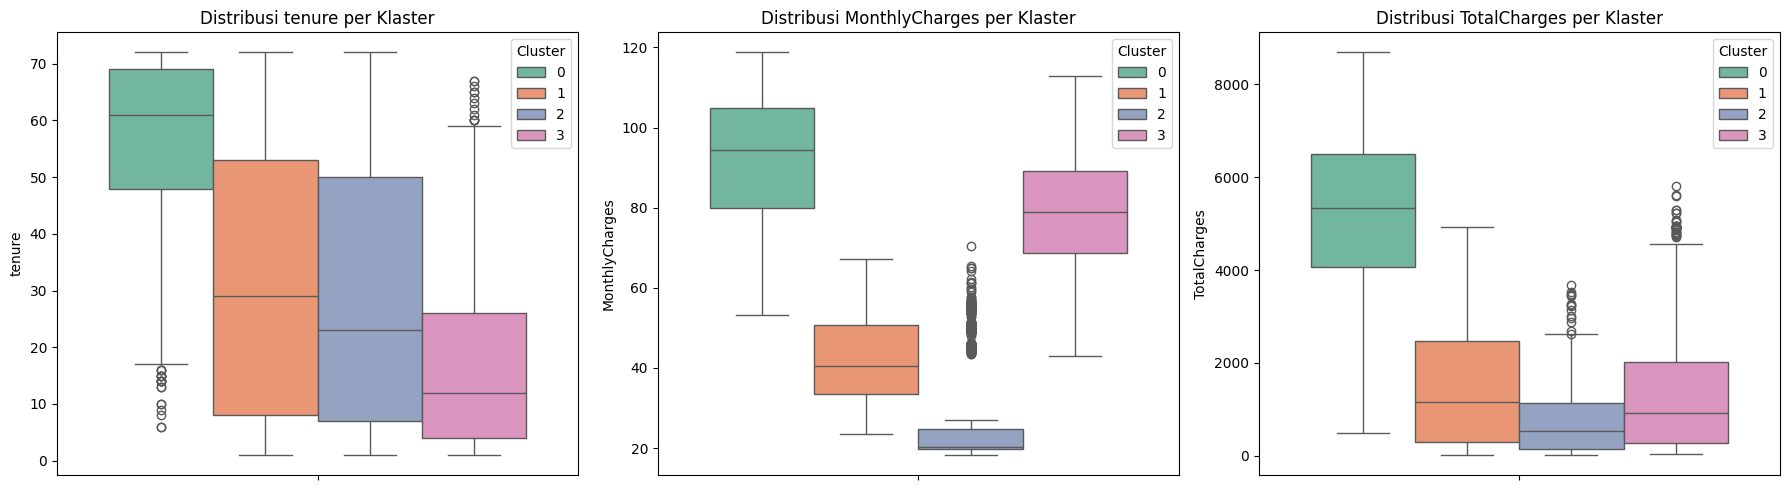

In [17]:
important_features = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(important_features):
    sns.boxplot(data=df, hue="Cluster", y=col, ax=axes[i], palette="Set2" )
    axes[i].set_title(f"Distribusi {col} per Klaster")

plt.tight_layout()
plt.show()

In [19]:
# Melihat karakteristik rata-rata setiap klaster
cluster_profile = df.groupby("Cluster")[important_features].mean()
print(cluster_profile)

# Melihat jumlah pelanggan di setiap klaster
print(df["Cluster"].value_counts())


            tenure  MonthlyCharges  TotalCharges
Cluster                                         
0        56.886089       91.859501   5255.301058
1        31.830882       41.992500   1500.433750
2        28.961649       24.880395    697.557928
3        16.362839       76.837390   1293.675219
Cluster
3    2621
0    1984
2    1747
1     680
Name: count, dtype: int64


In [20]:
pd.crosstab(
    df["Cluster"],
    df["Churn"],
    normalize="index"
)

Churn,0,1
Cluster,,
0,0.863407,0.136593
1,0.750000,0.250000
2,0.905552,0.094448
3,0.518123,0.481877


1. Cluster 0 (Hijau) – Loyal High-Spenders (Kelompok Paling Berharga)
- Karakteristik: Pelanggan lama yang menggunakan layanan premium/mahal. tenure mereka hampir menyentuh batas atas (rata-rata 56 bulan) dengan biaya bulanan tertinggi (~91.8).
- Insight Bisnis: Ini adalah kelompok VIP atau cash cow perusahaan Anda. Mereka sangat loyal dan menghasilkan profit terbesar (TotalCharges sangat tinggi).
- Rekomendasi Aksi: Jaga mereka dengan program loyalitas (loyalty program), berikan apresiasi eksklusif, dan pastikan kualitas pelayanan (customer service) untuk kelompok ini selalu prima agar tidak pindah ke kompetitor.

2. Cluster 1 (Orange) – Mid-Tier Core Users (Pelompok Menengah-Stabil)
- Karakteristik: Memiliki masa langganan sedang (~31 bulan) dengan pengeluaran yang moderat (~41.9). Distribusi datanya cukup seimbang dan stabil.
- Insight Bisnis: Pelanggan tipe ini biasanya menggunakan paket standar atau esensial. Mereka tidak terlalu mahal tetapi cukup konsisten menggunakan layanan Anda dalam jangka waktu menengah.
- Rekomendasi Aksi: Targetkan untuk strategi upselling dengan menawarkan diskon paket di atasnya (misal: penawaran khusus naik ke paket premium dengan tambahan harga sedikit).

3. Cluster 2 (Biru) – Low Revenue Customer (Pelanggan Hemat & Setia)
- Karakteristik: Masa langganan mereka sebenarnya lumayan lama (~29 bulan), tetapi pengeluaran bulanan mereka adalah yang paling murah di antara semua kelompok (~24.8).
- Insight Bisnis: Kelompok ini sangat sensitif terhadap harga (price-sensitive). Mereka memilih paket paling dasar (mungkin hanya telepon saja tanpa internet cepat) dan bertahan lama di paket tersebut tanpa berniat melakukan upgrade.
- Rekomendasi Aksi: Jangan dipaksa untuk upselling produk mahal karena berisiko membuat mereka kabur (churn). Lebih baik tawarkan produk tambahan (cross-selling) bernilai murah atau paket bundling hemat.

4. Cluster 3 (Pink) – New High-Spenders (Kelompok Risiko Churn Tinggi)
- Karakteristik: Kelompok dengan jumlah anggota terbanyak (2.621 pelanggan). Masa langganan mereka paling sebentar (rata-rata hanya 16 bulan), tetapi langsung mengambil paket dengan biaya bulanan yang cukup mahal (~76.8).
- Insight Bisnis: Ini adalah pelanggan baru yang langsung mendaftar layanan premium atau internet cepat. Berdasarkan pola industri, pelanggan baru dengan biaya bulanan tinggi memiliki risiko churn (berhenti langganan) paling besar sebelum mereka mencapai fase loyalitas.
- Rekomendasi Aksi: Fokuskan strategi retensi di sini. Lakukan pemantauan aktif (active engagement), berikan panduan optimasi layanan, atau tawarkan kontrak jangka panjang (misal: kontrak 1-2 tahun) dengan potongan harga agar mereka terikat lebih lama dan bergeser menjadi seperti Cluster 0.